In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.train_EEGNet import train_model_cv, train_model_within_subject
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import mlflow

np.random.seed(42)
torch.manual_seed(42)


/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA LOAD

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
subjects = data_22['subject_ids'] 

X_22 = data_22['X'] 
y_22 = data_22['y'] 

X_22_multiband = data_22_multiband['X'] 
y_22_multiband = data_22_multiband['y'] 

X_11 = data_11['X'] 
y_11 = data_11['y'] 

X_11_multiband = data_11_multiband['X'] 
y_11_multiband = data_11_multiband['y'] 

In [4]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

# Tests with 22 channels

## 22 channels (raw + normalization)

In [5]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

2026/05/13 10:18:22 INFO mlflow.tracking.fluent: Experiment with name 'BCI_EEGNet' does not exist. Creating a new experiment.
2026/05/13 10:20:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:20:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8879 | Test Acc: 0.7343


2026/05/13 10:20:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 10:22:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:22:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9017 | Test Acc: 0.5347


2026/05/13 10:22:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 10:23:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:23:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Early stopping in epoch 99. Best train loss: 0.2489


2026/05/13 10:34:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.9113 | Test Acc: 0.5417


2026/05/13 10:34:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 10:34:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6430 ± 0.0705


## 22 channels + laplacian filter on C3 and C4

In [6]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

Early stopping in epoch 94. Best train loss: 0.2792


2026/05/13 10:36:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 10:36:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8966 | Test Acc: 0.7692


2026/05/13 10:36:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 10:38:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:38:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9096 | Test Acc: 0.5486


...

Fold 8 | Subject A08 | Train Acc: 0.9017 | Test Acc: 0.6736


2026/05/13 10:48:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 10:50:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9026 | Test Acc: 0.5556


2026/05/13 10:50:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 10:50:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6662 ± 0.0870


## 22 channels - only mu band

In [7]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

2026/05/13 10:51:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:51:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8610 | Test Acc: 0.6224


2026/05/13 10:51:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 10:53:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:53:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.8800 | Test Acc: 0.5208


2026/05/13 10:53:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 10:55:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 10:55:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.8565 | Test Acc: 0.6944


2026/05/13 11:03:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:03:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:05:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.8643 | Test Acc: 0.5486


2026/05/13 11:05:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:05:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6237 ± 0.0733


## 22 channels - mu + beta band

In [8]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

2026/05/13 11:09:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:09:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9105 | Test Acc: 0.7622


2026/05/13 11:09:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:12:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:12:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9296 | Test Acc: 0.5417


2026/05/13 11:12:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                           

...

Fold 8 | Subject A08 | Train Acc: 0.9252 | Test Acc: 0.6667


2026/05/13 11:28:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:30:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9417 | Test Acc: 0.5000


2026/05/13 11:30:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:30:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6531 ± 0.0922


# Tests with 11 channels

## 11 channels (raw + normalization)

In [9]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

2026/05/13 11:31:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:31:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8818 | Test Acc: 0.7413


2026/05/13 11:31:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                           

Early stopping in epoch 96. Best train loss: 0.2704


2026/05/13 11:32:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 11:32:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.8826 | Test Acc: 0.7847


2026/05/13 11:42:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:42:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:43:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9009 | Test Acc: 0.5556


2026/05/13 11:43:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:43:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6585 ± 0.0834


## 11 channels + laplacian filter on C3 and C4

In [10]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

2026/05/13 11:44:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:44:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8888 | Test Acc: 0.7832


2026/05/13 11:45:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:46:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:46:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9052 | Test Acc: 0.6042


2026/05/13 11:46:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:48:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:48:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9139 | Test Acc: 0.7083


2026/05/13 11:55:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:55:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 11:56:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9122 | Test Acc: 0.6042


2026/05/13 11:56:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 11:57:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6778 ± 0.0665


## 11 channels - only mu band

In [11]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

2026/05/13 11:58:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 11:58:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8549 | Test Acc: 0.6573


2026/05/13 11:58:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                           

Early stopping in epoch 96. Best train loss: 0.3297


2026/05/13 11:59:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 11:59:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.8452 | Test Acc: 0.6528


2026/05/13 12:08:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 12:09:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 12:10:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.8652 | Test Acc: 0.5069


2026/05/13 12:10:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 12:10:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6221 ± 0.0987


## 11 channels - mu + beta band

In [12]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

2026/05/13 12:12:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 12:12:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9149 | Test Acc: 0.7343


2026/05/13 12:12:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 12:15:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 12:15:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9200 | Test Acc: 0.5417


2026/05/13 12:15:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 12:17:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/05/13 12:17:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9252 | Test Acc: 0.6250


2026/05/13 12:28:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 12:28:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/13 12:31:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9217 | Test Acc: 0.4931


2026/05/13 12:31:04 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 12:31:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6492 ± 0.0890


# Data Augmentation

## 22 channels + laplace + data augmentation

### 100 Epochs

In [13]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

Early stopping in epoch 135. Best train loss: 0.4300


2026/05/13 12:34:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 12:34:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.7732 | Test Acc: 0.7622


2026/05/13 12:34:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping in epoch 184. Best train loss: 0.3763


...

Early stopping in epoch 156. Best train loss: 0.3980


2026/05/13 13:05:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8070 | Test Acc: 0.5625


2026/05/13 13:05:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 13:06:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6662 ± 0.0783


## 11 channels + laplace + data augmentation

### 100 Epochs

In [14]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11_aug')

Early stopping in epoch 152. Best train loss: 0.4209


2026/05/13 13:08:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:08:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.7854 | Test Acc: 0.7622


2026/05/13 13:08:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping in epoch 172. Best train loss: 0.4143


...

Early stopping in epoch 115. Best train loss: 0.4298


2026/05/13 13:25:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.7722 | Test Acc: 0.5556


2026/05/13 13:25:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/13 13:25:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6554 ± 0.0811


# Visualization

/tmp/ipykernel_219273/3439218663.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')
/tmp/ipykernel_219273/3439218663.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(acc_matrix.T, labels=names, patch_artist=True,


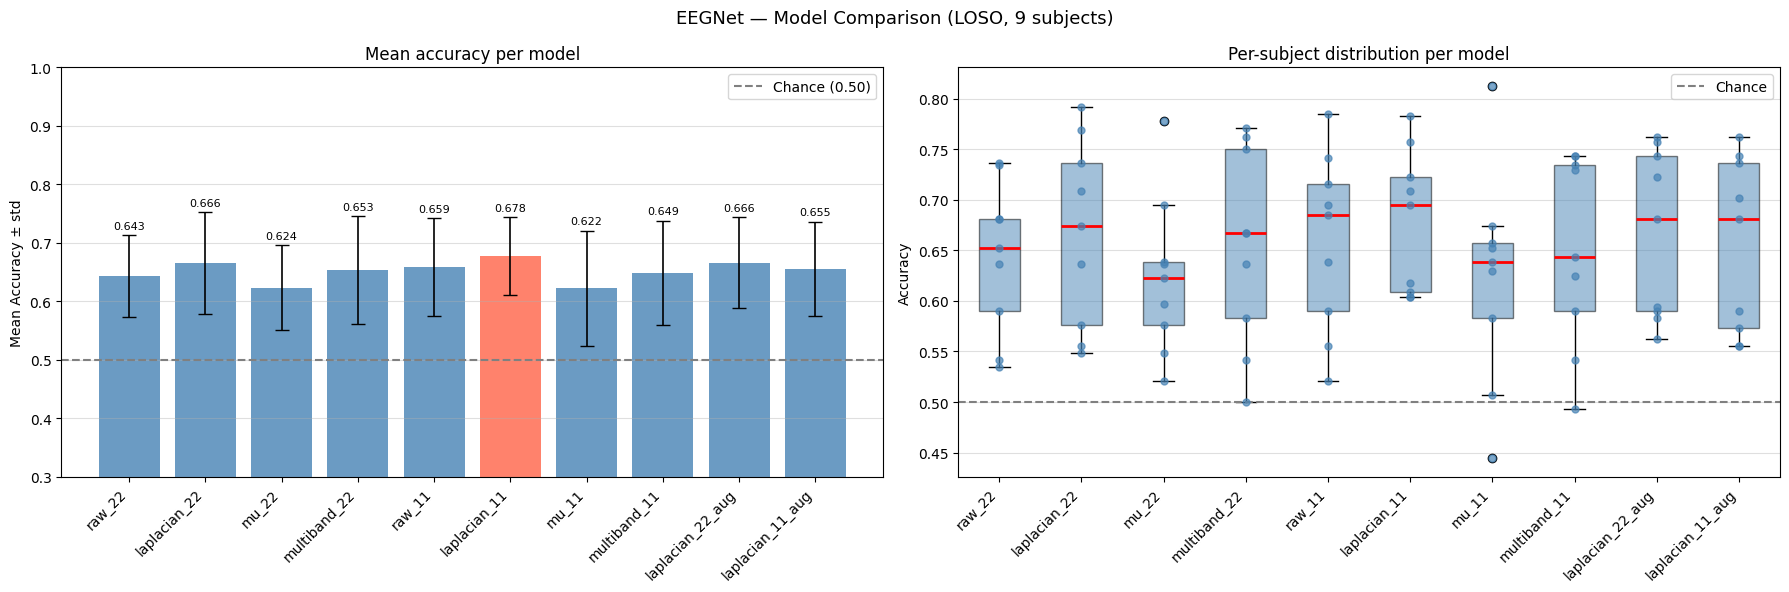

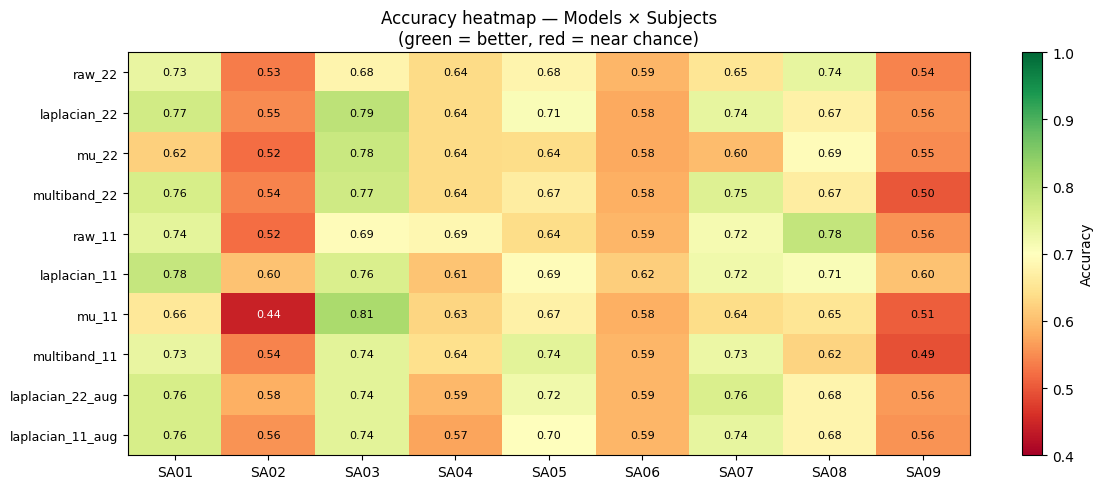

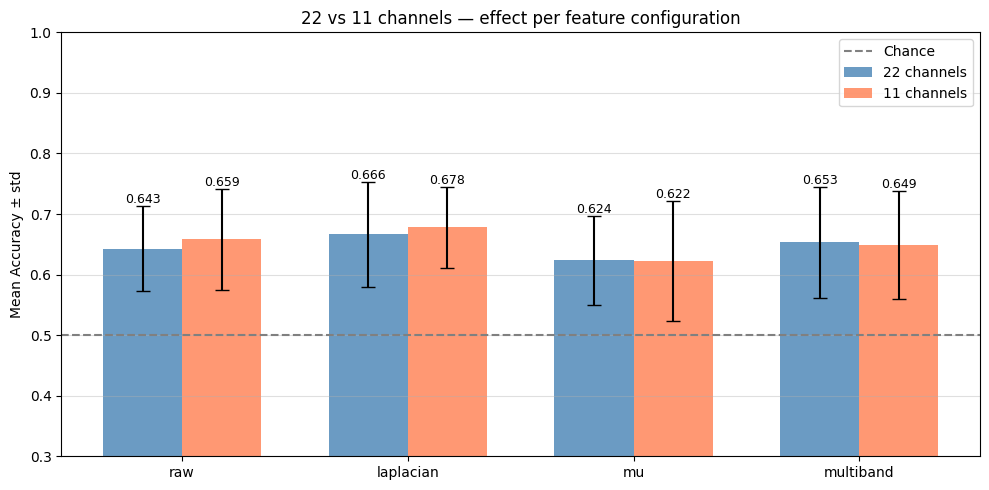

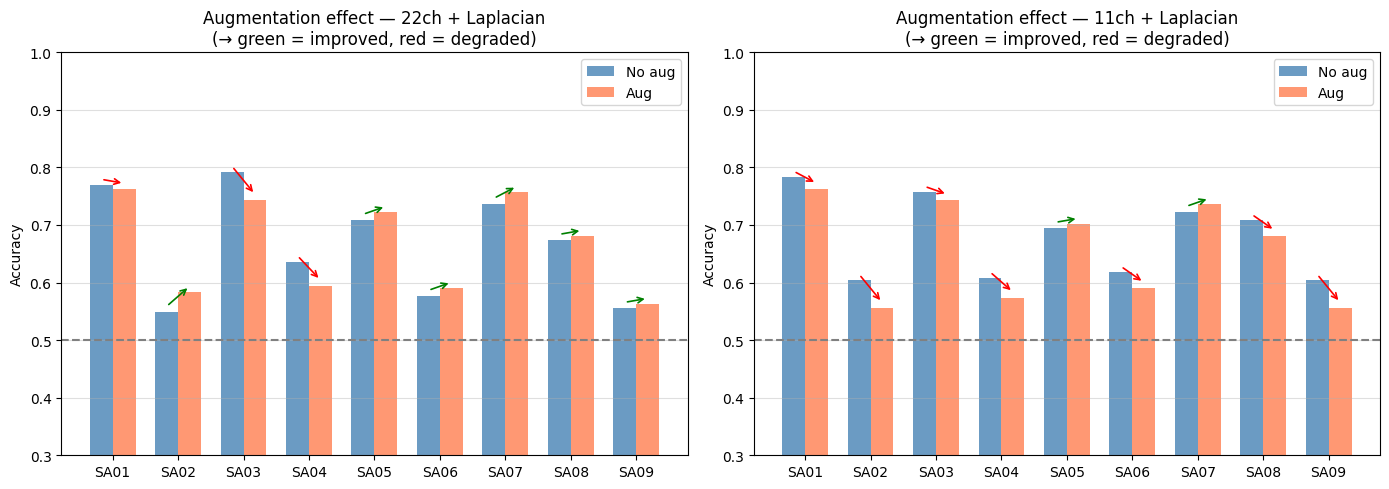

Best EEGNet model: laplacian_11 — 0.6778


In [15]:
import matplotlib.patches as mpatches

CHANCE = 0.5
SAVE_DIR = '../figures'
os.makedirs(SAVE_DIR, exist_ok=True)

names      = models['name']
accs       = models['accuracies']     
acc_matrix = np.array(accs)         
means      = acc_matrix.mean(axis=1)
stds       = acc_matrix.std(axis=1)
n_subjects = len(np.unique(subjects))
subj_labels = [f'S{s}' for s in np.unique(subjects)]


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EEGNet — Model Comparison (LOSO, 9 subjects)', fontsize=13)

ax = axes[0]
colors = ['tomato' if m == means.max() else 'steelblue' for m in means]
bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.8, error_kw=dict(elinewidth=1.2))
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
ax.axhline(CHANCE, color='gray', linestyle='--', label='Chance (0.50)')
ax.set_ylim(0.3, 1.0); ax.set_ylabel('Mean Accuracy ± std')
ax.set_title('Mean accuracy per model')
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend(); ax.grid(axis='y', alpha=0.4)

ax = axes[1]
bp = ax.boxplot(acc_matrix.T, labels=names, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.5)
for i, col in enumerate(acc_matrix):
    ax.scatter([i+1]*n_subjects, col, alpha=0.7, color='steelblue', s=25, zorder=3)
ax.axhline(CHANCE, color='gray', linestyle='--', label='Chance')
ax.set_ylabel('Accuracy'); ax.set_title('Per-subject distribution per model')
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend(); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eegnet_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(acc_matrix, aspect='auto', cmap='RdYlGn', vmin=0.4, vmax=1.0)
plt.colorbar(im, ax=ax, label='Accuracy')
ax.set_xticks(range(n_subjects));   ax.set_xticklabels(subj_labels, fontsize=10)
ax.set_yticks(range(len(names)));   ax.set_yticklabels(names, fontsize=9)
for i in range(len(names)):
    for j in range(n_subjects):
        ax.text(j, i, f'{acc_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='black' if 0.45 < acc_matrix[i,j] < 0.85 else 'white')
ax.set_title('Accuracy heatmap — Models × Subjects\n(green = better, red = near chance)')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eegnet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


feat_configs = ['raw', 'laplacian', 'mu', 'multiband']
pairs = [
    (f'{f}_22', f'{f}_11', f)
    for f in feat_configs
    if f'{f}_22' in names and f'{f}_11' in names
]

x = np.arange(len(pairs))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
m22 = [means[names.index(a)] for a,_,_ in pairs]
m11 = [means[names.index(b)] for _,b,_ in pairs]
s22 = [stds [names.index(a)] for a,_,_ in pairs]
s11 = [stds [names.index(b)] for _,b,_ in pairs]
labels = [l for _,_,l in pairs]

b1 = ax.bar(x - w/2, m22, w, yerr=s22, capsize=5, label='22 channels', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, m11, w, yerr=s11, capsize=5, label='11 channels', color='coral',     alpha=0.8)
ax.bar_label(b1, fmt='%.3f', fontsize=9); ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.axhline(CHANCE, color='gray', linestyle='--', label='Chance')
ax.set_ylim(0.3, 1.0); ax.set_ylabel('Mean Accuracy ± std')
ax.set_title('22 vs 11 channels — effect per feature configuration')
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/eegnet_channels.png', dpi=150, bbox_inches='tight')
plt.show()


aug_pairs = [
    ('laplacian_22', 'laplacian_22_aug', '22ch + Laplacian'),
    ('laplacian_11', 'laplacian_11_aug', '11ch + Laplacian'),
]
available = [(a, b, lbl) for a, b, lbl in aug_pairs if a in names and b in names]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(7*len(available), 5))
    if len(available) == 1: axes = [axes]

    for ax, (no_aug, aug, lbl) in zip(axes, available):
        no_aug_accs = acc_matrix[names.index(no_aug)]
        aug_accs    = acc_matrix[names.index(aug)]
        delta       = aug_accs - no_aug_accs

        xp = np.arange(n_subjects)
        ax.bar(xp - w/2, no_aug_accs, w, label='No aug', color='steelblue', alpha=0.8)
        ax.bar(xp + w/2, aug_accs,    w, label='Aug',    color='coral',     alpha=0.8)

        for j in range(n_subjects):
            color = 'green' if delta[j] > 0 else 'red'
            ax.annotate('', xy=(j + w/2, aug_accs[j] + 0.01),
                        xytext=(j - w/2, no_aug_accs[j] + 0.01),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

        ax.set_xticks(xp); ax.set_xticklabels(subj_labels)
        ax.axhline(CHANCE, color='gray', linestyle='--')
        ax.set_ylim(0.3, 1.0); ax.set_ylabel('Accuracy')
        ax.set_title(f'Augmentation effect — {lbl}\n(→ green = improved, red = degraded)')
        ax.legend(); ax.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/eegnet_augmentation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Best EEGNet model: {names[np.argmax(means)]} — {means.max():.4f}")

# Within Subject

In [5]:
models_within, accs_within = train_model_within_subject(
    X_11, y_11, subjects,
    transforms=['laplacian'],
    epochs=100, lr=0.0003, patience=20
)

print(f"Within-subject: {np.mean(accs_within):.3f} ± {np.std(accs_within):.3f}")

Early stopping época 48. Best val: 0.8621


Subject A01 | Train: 0.8621 | Test: 0.7931


Early stopping época 25. Best val: 0.6897


Subject A02 | Train: 0.6897 | Test: 0.5517


Early stopping época 53. Best val: 0.8966


...

Subject A07 | Train: 0.8276 | Test: 0.7931


Early stopping época 22. Best val: 0.5862


Subject A08 | Train: 0.5862 | Test: 0.6552


Early stopping época 34. Best val: 0.7586


Subject A09 | Train: 0.7586 | Test: 0.7241

Mean Within-Subject Accuracy: 0.6743 ± 0.1418
Within-subject: 0.674 ± 0.142
